# Quick, Draw! — Data Exploration

Print the **head** of the 3 project classes (`cat`, `apple`, `car`).

The per-category `.bin` files are downloaded on first run by the [`quickdraw`](https://quickdraw.readthedocs.io) package (via the helpers in [`utils/data_import.py`](utils/data_import.py)) and cached under `data/binary/`.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Make src/ importable whether the kernel starts at the repo root, in src/, or in src/pca/.
for cand in (Path.cwd(), *Path.cwd().parents):
    if (cand / "utils" / "data_import.py").exists():
        sys.path.insert(0, str(cand)); break
    if (cand / "src" / "utils" / "data_import.py").exists():
        sys.path.insert(0, str(cand / "src")); break

from utils.data_import import CLASSES, load_group, drawing_to_record

CLASSES

['cat', 'apple', 'car']

## Load the classes

Each `QuickDrawDataGroup` downloads its category's `.bin` on first use, then reads from the cache. We load a sample of each class into a `pandas` DataFrame of drawing metadata.

In [2]:
SAMPLE = 100  # drawings loaded per class (the full .bin is still cached)

frames = {}
for name in CLASSES:
    group = load_group(name, max_drawings=SAMPLE)
    frames[name] = pd.DataFrame(drawing_to_record(d) for d in group.drawings)

{name: df.shape for name, df in frames.items()}

loading cat drawings
load complete
loading apple drawings
load complete
loading car drawings
load complete


{'cat': (100, 5), 'apple': (100, 5), 'car': (100, 5)}

## Head of each class

In [3]:
from IPython.display import display

for name, df in frames.items():
    print(f"=== {name} ===")
    display(df.head())

=== cat ===


,key_id,country,recognized,timestamp,strokes
0,5201136883597312,VE,True,1488497110,9
1,4647694628814848,BR,True,1490553834,10
2,6411036099870720,RO,True,1489829768,15
3,6196755135725568,US,True,1485360351,13
4,4597292839469056,ID,True,1485657736,9


=== apple ===


,key_id,country,recognized,timestamp,strokes
0,6420579601088512,US,False,1489184277,6
1,4986110117675008,RU,True,1488954584,2
2,6489082920173568,GB,True,1489149693,2
3,4587619411296256,US,True,1489687314,1
4,5198601426829312,TH,True,1490798117,3


=== car ===


,key_id,country,recognized,timestamp,strokes
0,4819414685843456,PH,True,1488334911,3
1,6193826576203776,CA,True,1490828909,8
2,5064695469834240,SA,False,1489169914,8
3,5648885127053312,TR,True,1490808234,5
4,4858658959654912,GB,True,1489779842,3


## First N sketches of each class

One row per class, showing the first 3 drawings (`get_drawing(index=...)` / the first entries of `group.drawings`). `quickdraw` renders each drawing to a PIL image.

loading cat drawings
load complete
loading apple drawings
load complete
loading car drawings
load complete


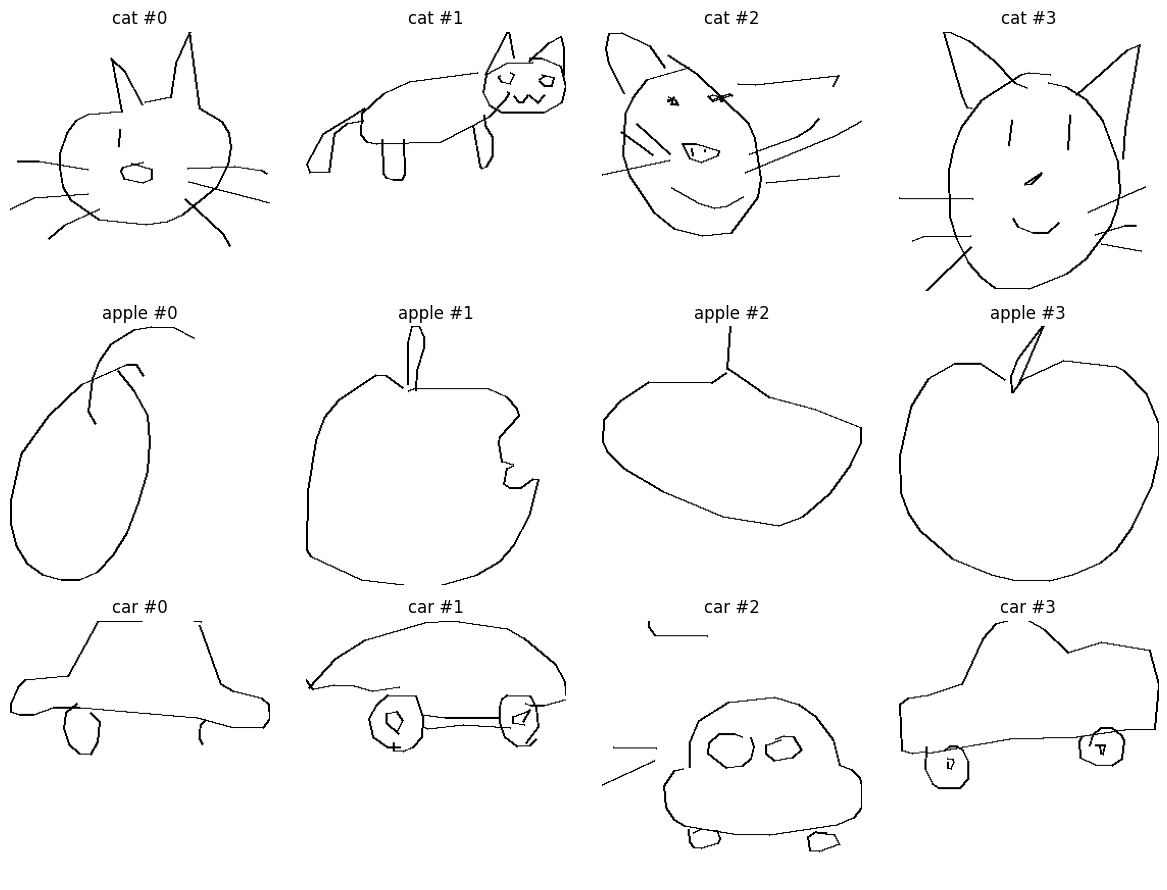

In [4]:
import matplotlib.pyplot as plt

N = 4  # first N sketches per class

fig, axes = plt.subplots(len(CLASSES), N, figsize=(3 * N, 3 * len(CLASSES)))
for row, name in enumerate(CLASSES):
    group = load_group(name, max_drawings=N)
    for col, drawing in enumerate(group.drawings):
        ax = axes[row, col]
        ax.imshow(drawing.image, cmap="gray")
        ax.axis("off")
        ax.set_title(f"{name} #{col}")
plt.tight_layout()
plt.show()

## MNIST image vector transformation (`mnist_data.py`)

Trace a single digit image through every transformation `load_digits()` applies internally, from the raw import down to the flat `[0, 1]` vector, then back up via `as_images()`. Each step below prints the vector's shape, dtype, and a slice of its values.

In [5]:
import numpy as np

# src/ is already on sys.path from the import cell above.
from utils.mnist_data import N_FEATURES, as_images
from keras.datasets import mnist

# Step 1: raw import -- keras hands back 28x28 uint8 bitmaps straight off disk.
(x_tr, y_tr), _ = mnist.load_data()
raw_image = x_tr[0]
print(f"1. raw import   shape={raw_image.shape} dtype={raw_image.dtype}")
print(raw_image[10])  # one row (28 pixels) of raw 0-255 ink values

# Step 2: flatten to a single row, still uint8.
flat_uint8 = raw_image.reshape(N_FEATURES)
print(f"\n2. flatten      shape={flat_uint8.shape} dtype={flat_uint8.dtype}")
print(flat_uint8)

# Step 3: cast + scale to float32 in [0, 1] -- the `X` contract load_digits() returns.
flat_scaled = flat_uint8.astype(np.float32) / 255.0
print(f"\n3. scale [0,1]  shape={flat_scaled.shape} dtype={flat_scaled.dtype}")
print(flat_scaled)

# Step 4: reshape back to an image via as_images(), the inverse used for plotting.
reshaped = as_images(flat_scaled)[0]
print(f"\n4. reshape back shape={reshaped.shape} dtype={reshaped.dtype}")
print(reshaped)

I0000 00:00:1784130349.796408    7843 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784130349.848863    7843 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784130351.255606    7843 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


1. raw import   shape=(28, 28) dtype=uint8
[  0   0   0   0   0   0   0   0   0  14   1 154 253  90   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]

2. flatten      shape=(784,) dtype=uint8
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0  

In [6]:
raw_image
raw_image.shape

(28, 28)

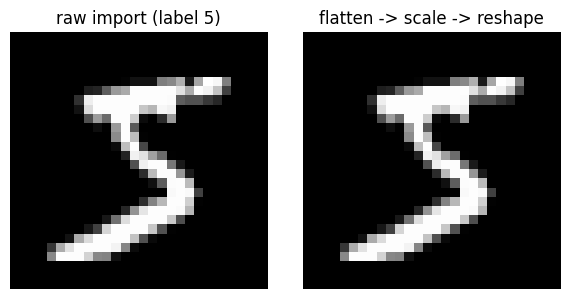

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(raw_image, cmap="gray")
axes[0].set_title(f"raw import (label {y_tr[0]})")
axes[0].axis("off")
axes[1].imshow(reshaped, cmap="gray")
axes[1].set_title("flatten -> scale -> reshape")
axes[1].axis("off")
plt.tight_layout()
plt.show()